In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt

from common import plotting
from common.config import Params, results_dir
from common.data import add_noise, sample_collocation, sample_measurements
from common.model import pde_snapshots
from common.pinn import PINN, train_pinn
from common.surrogates import solve_surrogate_ode

OUT = results_dir("zad6")

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

PARAMS = Params(D=0.02, p=0.05, q=4.0)
T_END = 5.0
NX = 150
DT = 5e-4
NOISE_LEVEL = 0.05
NOISE_KIND = "gaussian_mixture"
N_DATA = 1200
N_COLLOCATION = 12000
EPOCHS = 2000


Using device: cpu


In [2]:
x_true, t_true, u_true_clean = pde_snapshots(PARAMS, T_END, NX, DT, init_kind="localized", save_every=10)
rng = np.random.default_rng(123)
u_true_noisy = add_noise(u_true_clean, NOISE_KIND, NOISE_LEVEL, rng)
print(f"PDE data generated: u_true {u_true_clean.shape}, t_true {t_true.shape}")

X_u_train, u_train = sample_measurements(x_true, t_true, u_true_noisy, N_DATA, rng)
X_f_train = sample_collocation(N_COLLOCATION, T_END, np.random.default_rng(1234))

X_u_train_t = torch.tensor(X_u_train, dtype=torch.float32).to(DEVICE)
u_train_t = torch.tensor(u_train, dtype=torch.float32).to(DEVICE)
X_f_train_t = torch.tensor(X_f_train, dtype=torch.float32).to(DEVICE)
print(f"Training data: {X_u_train_t.shape}, collocation points: {X_f_train_t.shape}")


PDE data generated: u_true (150, 1001), t_true (1001,)
Training data: torch.Size([1200, 2]), collocation points: torch.Size([12000, 2])


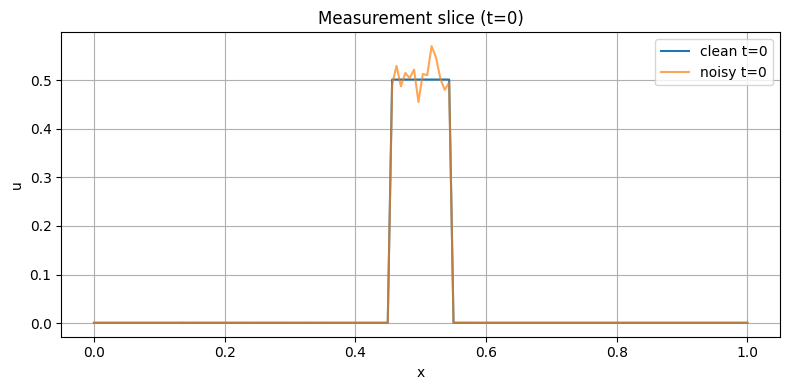

In [3]:
plotting.plot_noise_slice(x_true, u_true_clean, u_true_noisy, OUT / "noise_slice_t0.png")

Epoch 500/2000, Loss: 0.047954 (Data: 0.010853, Phy: 0.018586, lambda=1.996, LR=9.00e-04)
Epoch 1000/2000, Loss: 0.030599 (Data: 0.009107, Phy: 0.010746, lambda=2.000, LR=8.10e-04)
Epoch 1500/2000, Loss: 0.049066 (Data: 0.009607, Phy: 0.019730, lambda=2.000, LR=7.29e-04)
Epoch 2000/2000, Loss: 0.013755 (Data: 0.008227, Phy: 0.002764, lambda=2.000, LR=6.56e-04)
Training finished in 75.75s


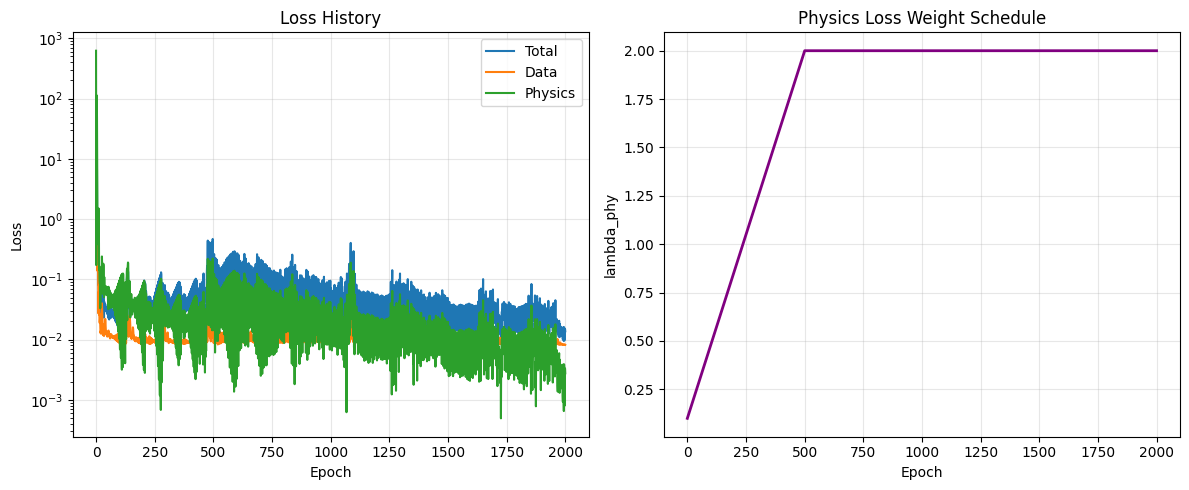

In [4]:
model = PINN(hidden_dim=64, num_layers=5, use_residual=True).to(DEVICE)
history, train_time = train_pinn(
    model,
    X_u_train_t[:, 0:1], X_u_train_t[:, 1:2], u_train_t,
    X_f_train_t[:, 0:1], X_f_train_t[:, 1:2],
    PARAMS,
    epochs=EPOCHS,
)
print(f"Training finished in {train_time:.2f}s")

loss_arr = np.asarray(history)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_arr[:, 0], label="Total", linewidth=1.5)
plt.plot(loss_arr[:, 1], label="Data", linewidth=1.5)
plt.plot(loss_arr[:, 2], label="Physics", linewidth=1.5)
plt.yscale("log")
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_arr[:, 3], label="lambda_phy", linewidth=2, color="purple")
plt.title("Physics Loss Weight Schedule")
plt.xlabel("Epoch")
plt.ylabel("lambda_phy")
plt.grid(True, alpha=0.3)
plotting.savefig(OUT / "loss_history_improved.png", dpi=150)
plt.show()


In [5]:
X_grid, T_grid = np.meshgrid(x_true, t_true)
x_eval = torch.tensor(X_grid.flatten()[:, None], dtype=torch.float32).to(DEVICE)
t_eval = torch.tensor(T_grid.flatten()[:, None], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    u_pred_grid = model(x_eval, t_eval).cpu().numpy().reshape(X_grid.shape)

abs_error = np.abs(u_true_clean.T - u_pred_grid)
mae = float(np.mean(abs_error))
rmse = float(np.sqrt(np.mean(abs_error ** 2)))
rel_l2 = float(np.linalg.norm(u_true_clean.T - u_pred_grid) / np.linalg.norm(u_true_clean.T))
print(f"MAE  = {mae:.6f}\nRMSE = {rmse:.6f}\nrelL2 = {rel_l2:.6f}")

(OUT / "pinn_metrics.txt").write_text(
    f"MAE  = {mae:.6f}\n"
    f"RMSE = {rmse:.6f}\n"
    f"relL2 = {rel_l2:.6f}\n"
    f"Training time: {train_time:.2f}s\n"
    f"Network: 64 hidden units, 5 layers with residual connections\n"
    f"Epochs: {EPOCHS}\n"
)

sol_ode = solve_surrogate_ode(PARAMS.p, PARAMS.q, float(np.mean(u_true_clean[:, 0])), [t_true[0], t_true[-1]], t_eval=t_true)
u_ode = sol_ode.y.T


MAE  = 0.031354
RMSE = 0.061202
relL2 = 0.068676


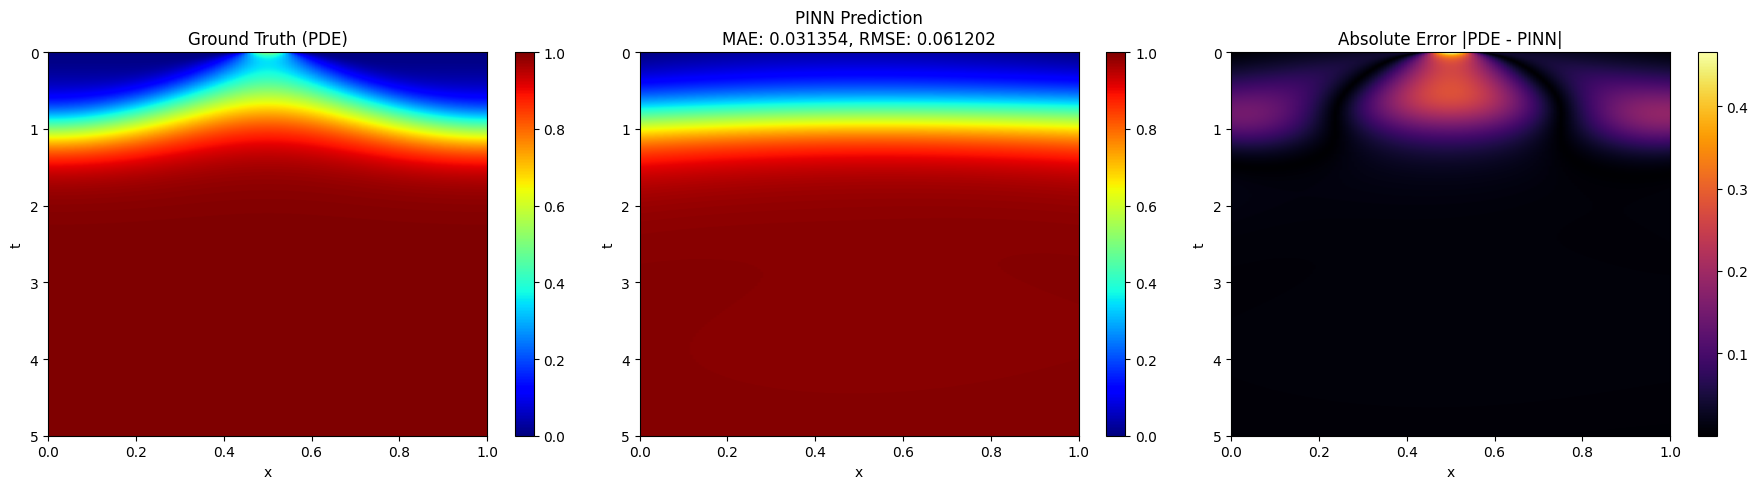

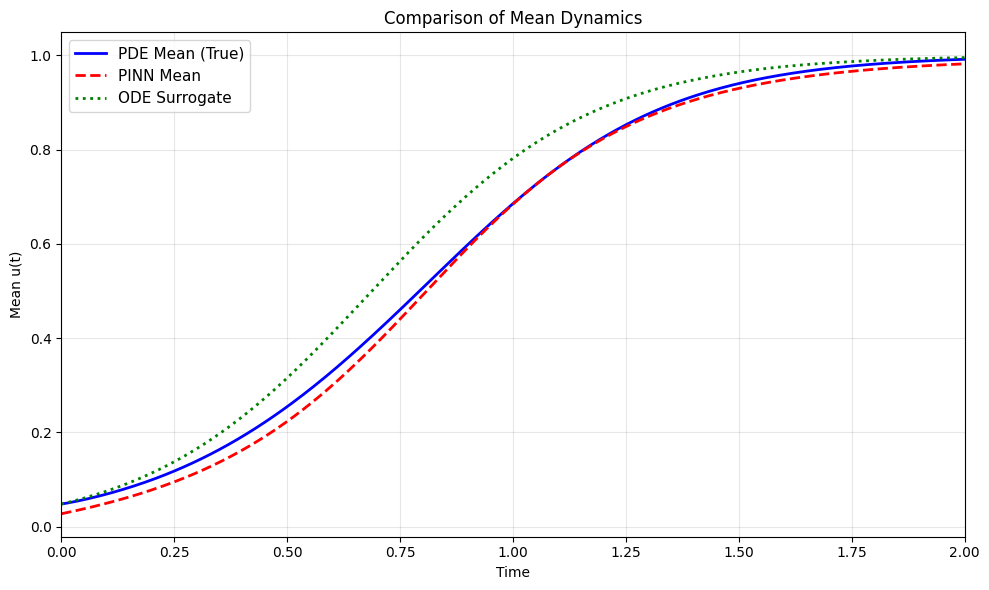

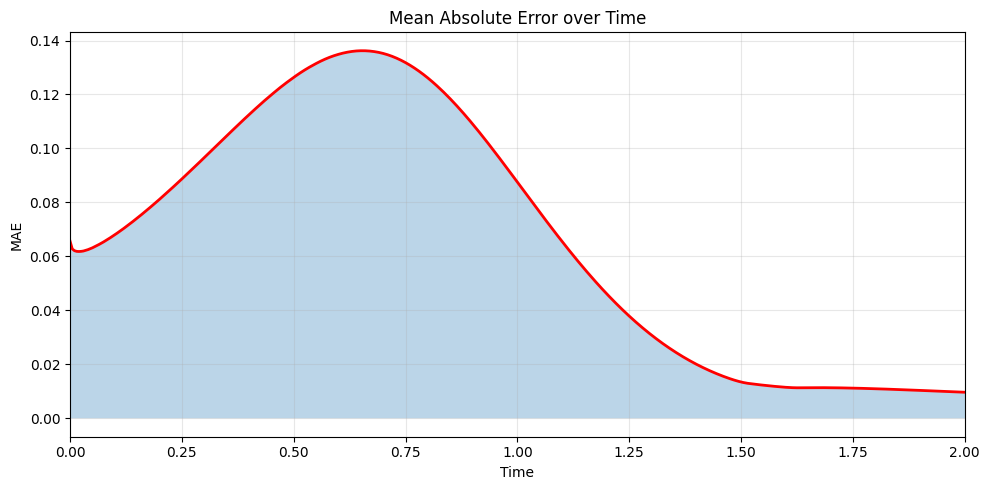

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im1 = axes[0].imshow(u_true_clean.T, extent=[0, 1, T_END, 0], aspect="auto", cmap="jet", vmin=0, vmax=1)
axes[0].set_title("Ground Truth (PDE)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(u_pred_grid, extent=[0, 1, T_END, 0], aspect="auto", cmap="jet", vmin=0, vmax=1)
axes[1].set_title(f"PINN Prediction\nMAE: {mae:.6f}, RMSE: {rmse:.6f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(abs_error, extent=[0, 1, T_END, 0], aspect="auto", cmap="inferno")
axes[2].set_title("Absolute Error |PDE - PINN|")
axes[2].set_xlabel("x")
axes[2].set_ylabel("t")
plt.colorbar(im3, ax=axes[2])
plotting.savefig(OUT / "pinn_results_heatmap_improved.png", dpi=150)
plt.show()

u_pinn_mean = np.mean(u_pred_grid, axis=1)
u_true_mean = np.mean(u_true_clean.T, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, "b-", linewidth=2, label="PDE Mean (True)")
plt.plot(t_true, u_pinn_mean, "r--", linewidth=2, label="PINN Mean")
plt.plot(t_true, u_ode, "g:", linewidth=2, label="ODE Surrogate")
plt.title("Comparison of Mean Dynamics")
plt.xlabel("Time")
plt.ylabel("Mean u(t)")
plt.xlim(0, 2)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plotting.savefig(OUT / "pinn_vs_pde_vs_ode_improved.png", dpi=150)
plt.show()

mean_error = np.mean(abs_error, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(t_true, mean_error, "r-", linewidth=2)
plt.fill_between(t_true, 0, mean_error, alpha=0.3)
plt.title("Mean Absolute Error over Time")
plt.xlabel("Time")
plt.ylabel("MAE")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plotting.savefig(OUT / "error_over_time.png", dpi=150)
plt.show()
